In [68]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import yaml, os, copy, time

from distgen import Generator

from specific_particle_tracer import SpecificParticleTracer, HemisphericalTip, FlatCathode
from specific_particle_tracer.distributions import flat_distribution_to_hemisphere
from specific_particle_tracer.constants import ELEMENTARY_CHARGE

from GPT_tools.gpt_plot import gpt_plot_dist1d, gpt_plot_dist2d
from GPT_tools.image_charge import MakeMetalParticleGroup, MakeSemiconductorParticleGroup, MakeEnergyOffsetParticleGroup
from GPT_tools.image_charge import MTE_model, QE_model, getValueFromSettings, getSemiconductorEexc

template_dir = r'C:\Users\acb20\OneDrive\Desktop\Claude\BEM\distgen'
DISTGEN_INPUT_FILE = os.path.join(template_dir,'distgen.in.yaml')

# ---------------------------------------------------------------------
# Settings for multi-threading

max_workers = 1   # number of threads on your computer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [95]:
# Some font size defaults
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
})

## Distgen


In [65]:
settings = {}

# ---------------------------------------------------------------------
# Settings for distgen

settings['random:type'] = 'pseudo'  # 'pseudo' = not Hammersley

settings['r_dist:sigma_xy:value'] = 2.5
settings['r_dist:sigma_xy:units'] = 'nm'
settings['r_dist:alpha:value'] = 0  # 0 = flat top, 1 = gaussian

settings['t_dist:sigma_t:value'] = 10
settings['t_dist:sigma_t:units'] = 'fs'
settings['t_dist:alpha:value'] = 0  # 0 = flat top, 1 = gaussian

# ---------------------------------------------------------------------
# Settings for cathode emission model

settings['cathode_type'] = 'semiconductor'  # metal, semiconductor, or distgen
settings['only_survivors'] = False 

# Metal only settings
if (settings['cathode_type'] == 'metal'):
    settings['photon_energy:value'] = 1.600 # 1.461
    settings['photon_energy:units'] = 'eV'
    
    settings['kT:value'] = 25e-3
    settings['kT:units'] = 'meV'
    
    settings['work_function:value'] = 1.4
    settings['work_function:units'] = 'eV'

# Semiconductor only settings
if (settings['cathode_type'] == 'semiconductor'):
    settings['photon_energy:value'] = 1.500
    settings['photon_energy:units'] = 'eV'
    
    settings['electron_affinity:value'] = -0.0
    settings['electron_affinity:units'] = 'eV'
    
    settings['energy_gap:value'] = 1.4
    settings['energy_gap:units'] = 'eV'

# distgen only settings
if (settings['cathode_type'] == 'distgen'):
    settings['start:MTE:value'] = 25
    settings['start:MTE:units'] = 'meV'

# ---------------------------------------------------------------------
# Settings for GPT

settings['gun_field:value'] = 0.1   # asymptotic field for large r
settings['gun_field:units'] = 'MV/m'

settings['plummer_radius:value'] = 1.0e-3
settings['plummer_radius:units'] = 'nm'

settings['cathode_z_offset:value'] = 3
settings['cathode_z_offset:units'] = 'nm'

settings['tmax'] = 1e-9
settings['zmax'] = 1.1e-6 

settings['R_sphere'] = 50e-9

# ---------------------------------------------------------------------
# RNG settings
rng = np.random.default_rng()

In [108]:
# ---------------------------------------------------------------------
# Make initial distribution

n_particles = 10000

verbose=True

# ---------------------------------------------------------------------

settings_copy = copy.copy(settings)
settings_copy['n_particle'] = n_particles
# ---------------------------------------------------------------------

if (settings['cathode_type'] == 'metal'):
    PG_initial = MakeMetalParticleGroup(settings_copy, DISTGEN_INPUT_FILE=DISTGEN_INPUT_FILE, verbose=verbose, only_survivors=settings_copy['only_survivors'], rng=rng)
elif (settings['cathode_type'] == 'semiconductor'):
    PG_initial = MakeSemiconductorParticleGroup(settings_copy, DISTGEN_INPUT_FILE=DISTGEN_INPUT_FILE, verbose=verbose, only_survivors=settings_copy['only_survivors'], rng=rng)
elif (settings['cathode_type'] == 'distgen'):
    if (not settings_copy['only_survivors']):
        raise ValueError("ERROR: only_survivors must be used with distgen")
    PG_initial = MakeEnergyOffsetParticleGroup(settings_copy, DISTGEN_INPUT_FILE=DISTGEN_INPUT_FILE, verbose=verbose)
else:
    raise ValueError("ERROR: bad cathode type")

PG_initial.weight = ELEMENTARY_CHARGE # Just to make sure, not really needed

Adding settings["gun_field"] = 100000.0 for use in GPT
Adding settings["cathode_z_offset"] = 3.0000000000000004e-09 for use in GPT
Adding settings["plummer_radius"] = 1.0000000000000002e-12 for use in GPT
Peak potential barrier at z = 57 nm
Eexc at surface = 0.2199970441667078, Eexc at peak = 0.11169985229054934


## Run

In [109]:
geometry = HemisphericalTip(E_gun=-settings_copy["gun_field"], z0=settings_copy["cathode_z_offset"], R=settings_copy['R_sphere'])
PG_run = flat_distribution_to_hemisphere(PG_initial, settings_copy['R_sphere'])

#geometry = FlatCathode(E_gun=-settings_copy["gun_field"], z0=settings_copy["cathode_z_offset"])
#PG_run = copy.deepcopy(PG_initial)

#t_max_plot = 1.0e-12
#t_out = np.linspace(0, t_max_plot, 300)
t_out = None

z_screen = 1e-6

tracer = SpecificParticleTracer(
    initial_particles=PG_run,
    n_emit=2,
    geometry=geometry,
    screens=[z_screen],   # 1 micron above the tip
    t_out=t_out,
    z_max=settings_copy['zmax'],   # stop tracking a particle once it's well past the screen
    t_max=settings_copy['tmax'],
    plummer_radius=settings_copy["plummer_radius"],
    backend='gpu',
    n_workers=max_workers,
    rtol=1.0e-8,
    atol=1.0e-12,
)

t_run_gpt = time.time()
screens, trajectories = tracer.run(verbose=True)
print(f'Elapsed: {time.time() - t_run_gpt} s')
print(f"{len(screens[-1])} of {len(PG_run)} particles reached the screen")

659 accepted step-batches across 5000 groups (backend=gpu)
Elapsed: 18.542304515838623 s
3899 of 10000 particles reached the screen


## Plots

In [ ]:
gpt_plot_dist1d(screens[-1], 'kinetic_energy', nbins=300)

In [ ]:
gpt_plot_dist2d(screens[-1], 'x', 'px', nbins=100)

In [60]:
def collect_trajectories(trajectories):
    """Return {id: (t_array, pos_array (n,3), mom_array (n,3))} by following each
    particle's id across the list of per-time-snapshot ParticleGroups."""
    by_id = {}
    for traj in trajectories:
        for i, pid in enumerate(traj.id):
            t_list, pos_list, mom_list = by_id.setdefault(pid, ([], [], []))
            t_list.append(traj.t[i])
            pos_list.append((traj.x[i], traj.y[i], traj.z[i]))
            mom_list.append((traj.px[i], traj.py[i], traj.pz[i]))
    return {
        pid: (np.array(t_list), np.array(pos_list), np.array(mom_list))
        for pid, (t_list, pos_list, mom_list) in by_id.items()
    }


by_id = collect_trajectories(trajectories)
print(f"tracked {len(by_id)} particle trajectories")

tracked 0 particle trajectories


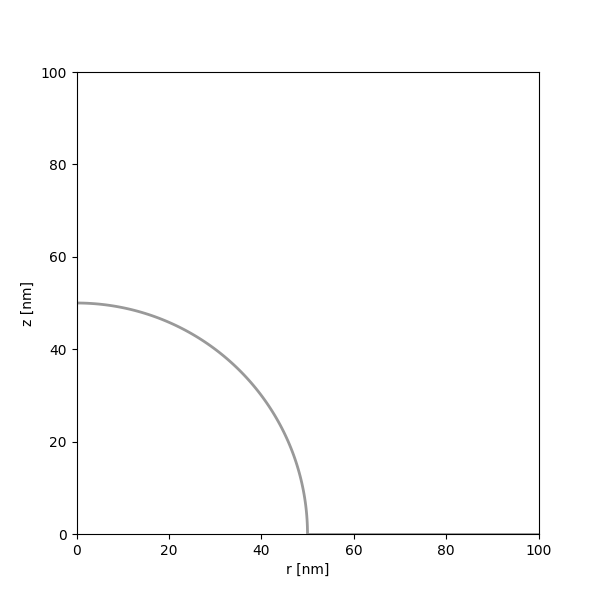

In [59]:
fig, ax = plt.subplots(figsize=(6, 6))

R = settings_copy['R_sphere']
z_plot_max = R * 2
r_plot_max = R * 2

theta = np.linspace(0, np.pi / 2, 100)
ax.plot(R * 1e9 * np.cos(theta), R * 1e9 * np.sin(theta), color="0.6", lw=2)
ax.plot([R * 1e9, r_plot_max * 1e9], [0, 0], color="0.6", lw=2)

for pid, (t, pos, mom) in by_id.items():
    ax.plot(np.sqrt(pos[:, 0]**2 + pos[:, 1]**2) * 1e9, pos[:, 2] * 1e9, lw=0.8, alpha=0.7)

ax.set_xlabel("r [nm]")
ax.set_ylabel("z [nm]")
ax.set_xlim(0, r_plot_max*1e9)
ax.set_ylim(0, z_plot_max*1e9)
ax.set_aspect("equal")
plt.show()